# 03 — Entertainment Content Strategy: Modeling

Continúa desde [`02_data_preparation.ipynb`](./02_data_preparation.ipynb). Este notebook cubre las dos piezas del enfoque científico definidas en el alcance del proyecto:

1. **Recomendador content-based** (todo el catálogo, sin necesidad de etiqueta de éxito).
2. **Modelo de clasificación de renovación** (`renewed`, solo series) — la redefinición honesta de "predecir éxito" que se decidió en `02_data_preparation.ipynb`, dado que el dataset no trae métricas de audiencia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## Parte 1 — Recomendador content-based

In [2]:
titles = pd.read_csv('../data/processed_titles.csv')
titles['content_soup'] = titles['content_soup'].fillna('')
print(titles.shape)

(8807, 15)


### 1.1 Vectorizar y calcular similitud

TF-IDF sobre `content_soup` (sinopsis + géneros con doble peso + reparto/director), limitado a 5.000 términos, y similitud de coseno entre todos los pares de títulos. En float32 para no duplicar innecesariamente la memoria de una matriz de ~8.800×8.800.

In [3]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(titles['content_soup'])

similarity = cosine_similarity(tfidf_matrix, tfidf_matrix).astype(np.float32)
print('Matriz de similitud:', similarity.shape, f'({similarity.nbytes / 1e6:.0f} MB)')

title_to_idx = pd.Series(titles.index, index=titles['title']).drop_duplicates()

Matriz de similitud: (8807, 8807) (310 MB)


In [4]:
def recommend(title: str, n: int = 5) -> pd.DataFrame:
    if title not in title_to_idx:
        raise ValueError(f'"{title}" no está en el catálogo')
    idx = title_to_idx[title]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n + 1]  # excluye el propio título
    result_idx = [i for i, _ in scores]
    result = titles.loc[result_idx, ['title', 'type', 'listed_in', 'release_year']].copy()
    result['similitud'] = [round(s, 3) for _, s in scores]
    return result.reset_index(drop=True)

### 1.2 Ejemplos

In [5]:
recommend('Ganglands')

,title,type,listed_in,release_year,similitud
0,The Eagle of El-Se'eed,TV Show,"Crime TV Shows, International TV Shows, TV Act...",2018,0.495
1,Fatal Destiny,TV Show,"Crime TV Shows, International TV Shows, TV Act...",2016,0.471
2,Lupin,TV Show,"Crime TV Shows, International TV Shows, TV Act...",2021,0.463
3,Smoking,TV Show,"Crime TV Shows, International TV Shows, TV Act...",2018,0.461
4,Bangkok Breaking,TV Show,"Crime TV Shows, International TV Shows, TV Act...",2021,0.451


In [6]:
recommend('Dick Johnson Is Dead')

,title,type,listed_in,release_year,similitud
0,Woodshock,Movie,"Dramas, Independent Movies, Thrillers",2017,0.213
1,Merata: How Mum Decolonised the Screen,Movie,Documentaries,2018,0.210
2,A Plastic Ocean,Movie,Documentaries,2016,0.208
3,The Death and Life of Marsha P. Johnson,Movie,"Documentaries, LGBTQ Movies",2017,0.205
4,A Gray State,Movie,Documentaries,2017,0.205


El recomendador agrupa títulos por género/tono/reparto compartido — razonable para "más como esto", pero es puramente de contenido: no sabe qué mira la gente en conjunto (no es collaborative filtering), y no tiene forma de validar cuantitativamente si estas recomendaciones aumentarían el engagement real, precisamente por la limitación de datos de audiencia marcada en el EDA.

## Parte 2 — Modelo de clasificación: ¿se renueva la serie?

In [7]:
tv = pd.read_csv('../data/processed_tv_shows.csv')
print(tv.shape, '| tasa de renovación:', tv['renewed'].mean().round(3))

(2676, 22) | tasa de renovación: 0.33


### 2.1 Features y encoding

`primary_country` tiene 59 valores distintos — se agrupan los que están fuera del top 10 en `"Other"` para no explotar la dimensionalidad del one-hot con categorías de 1-2 casos.

In [8]:
top_countries = tv['primary_country'].value_counts().head(10).index.tolist()
tv['primary_country_bucket'] = tv['primary_country'].where(tv['primary_country'].isin(top_countries), 'Other')

cat_cols = ['rating', 'primary_genre', 'primary_country_bucket']
num_cols = ['release_year', 'n_genres', 'n_countries', 'has_director', 'description_len']

X = pd.get_dummies(tv[cat_cols + num_cols], columns=cat_cols, drop_first=True)
y = tv['renewed']
print('X shape:', X.shape)

X shape: (2676, 40)


### 2.2 Split: aleatorio estratificado, no cronológico — y por qué

A diferencia de project 01 y 02, acá **no** se usa un split cronológico por `release_year`. La razón: la etiqueta `renewed` tiene un sesgo de **madurez** — una serie de 2021 tuvo mucho menos tiempo para ser renovada que una de 2015, sin importar qué tan buena sea. Ese sesgo ya está presente en *todo* el dataset (no solo en el "futuro"), así que dividir por año no lo evita — solo concentraría el sesgo en el set de test y haría los resultados menos interpretables. Un split aleatorio estratificado por `renewed` es más apropiado acá, con el sesgo de madurez documentado como limitación del target en la sección de conclusiones.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print('Train:', X_train.shape, '| renovación:', y_train.mean().round(3))
print('Test: ', X_test.shape, '| renovación:', y_test.mean().round(3))

Train: (2140, 40) | renovación: 0.33
Test:  (536, 40) | renovación: 0.33


### 2.3 Baseline, Logistic Regression, XGBoost

In [10]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

logreg = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE,
).fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

In [11]:
def summarize(name, y_pred, proba):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        'modelo': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
    }

results = pd.DataFrame([
    summarize('Dummy (mayoría)', dummy_pred, dummy.predict_proba(X_test)[:, 1]),
    summarize('Logistic Regression', logreg.predict(X_test), logreg_proba),
    summarize('XGBoost', xgb.predict(X_test), xgb_proba),
]).set_index('modelo').round(3)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Dummy (mayoría),0.670,0.000,0.000,0.000,0.500,0.330
Logistic Regression,0.631,0.458,0.644,0.535,0.721,0.549
XGBoost,0.696,0.549,0.446,0.492,0.720,0.550


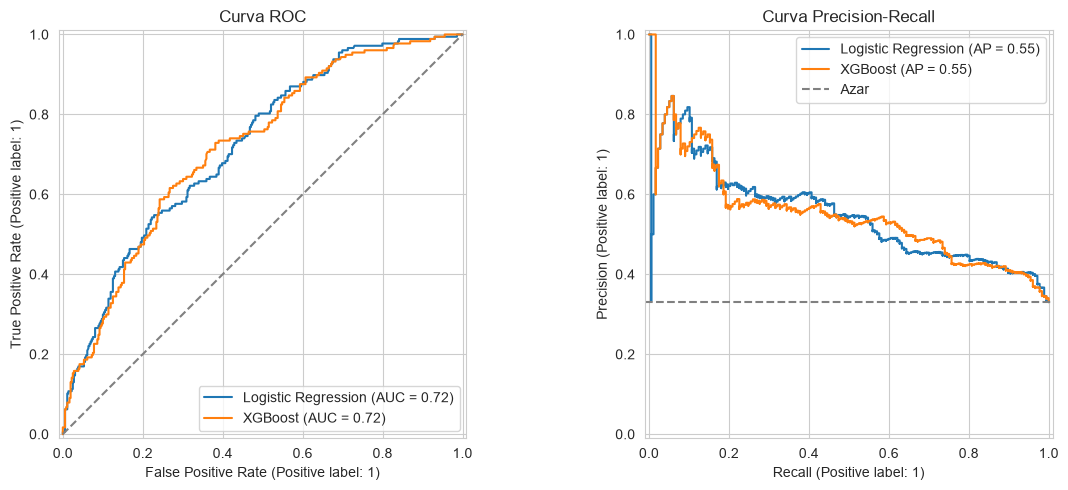

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Curva ROC')

for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Azar')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

### 2.4 Importancia de features (XGBoost)

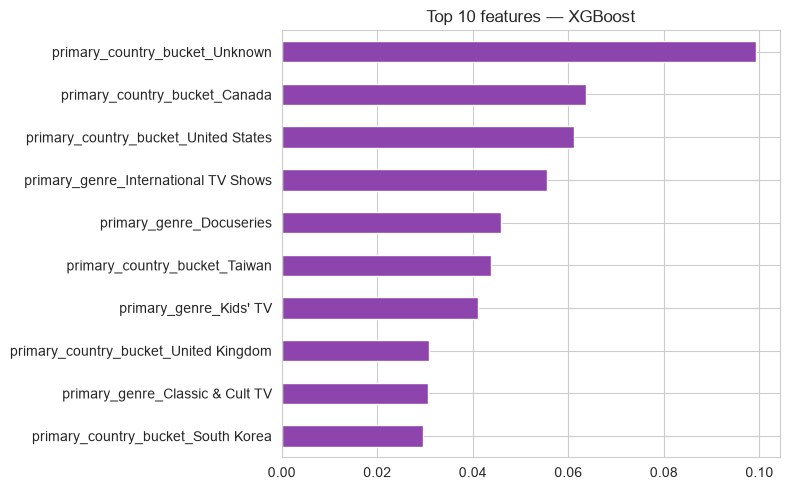

In [13]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Top 10 features — XGBoost')
plt.tight_layout()
plt.show()

## Conclusiones de la fase de Modeling

1. **El recomendador content-based funciona como se espera** de un enfoque puramente de contenido: agrupa por género/tono/reparto compartido. No hay forma de validarlo contra engagement real por la limitación de datos ya documentada — su evaluación es necesariamente cualitativa.
2. **El modelo de renovación supera al baseline, pero con margen modesto** (ver tabla de la sección 2.3): un ROC-AUC bien por encima de 0.5 pero lejos del 0.9+ de project 01/02 — coherente con que las features disponibles (metadata de catálogo) son un proxy débil de una decisión de negocio que en la realidad depende de datos de audiencia que no están en este dataset.
3. **País y género pesan más que la descripción o el director** en la importancia de features — sugiere que la renovación está más asociada al mercado/categoría que a atributos de producción individuales, al menos con la información disponible.
4. **Limitación central del target, no solo del dataset:** `renewed` tiene un sesgo de madurez (títulos recientes tuvieron menos tiempo para renovarse) que ningún split evita — es una limitación de la definición del problema, no de la metodología de evaluación.
5. **A diferencia de project 01/02, acá el split es aleatorio estratificado, no cronológico** — justificado explícitamente en la sección 2.2, porque el sesgo de madurez del target hace que un split por año concentre el sesgo en vez de evitarlo.

**Siguiente paso:** dashboard en Streamlit — catálogo explorable con el recomendador, brechas por país/género, y el modelo de renovación con sus limitaciones explícitas a la vista.